# Exploration du Dataset AI4I 2020

> Dataset industriel de maintenance prédictive — 10 000 points de données
> issus d'une machine de fraisage simulée (synthétique).

**Objectif :** Comprendre la distribution des variables et des modes de panne
avant de construire le modèle ML.

**Source :** S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications", AI4I 2020.

## 1. Importation des bibliothèques

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## 2. Chargement des données

In [14]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

## 3. Analyse de forme

In [15]:
print("Shape :", df.shape)
print("\nColonnes :", df.columns.tolist())
print("\nTypes :\n", df.dtypes)
df.head()

Shape : (10000, 14)

Colonnes : ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Types :
 UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 4. Statistiques descriptives

In [16]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 5. Valeurs manquantes

In [17]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

## 6. Taux de pannes

In [18]:
print(f"Pannes : {df['Machine failure'].sum()} / {len(df)} ({df['Machine failure'].mean()*100:.2f}%)")

Pannes : 339 / 10000 (3.39%)


## 7. Visualisations

### Distribution de la variable cible (Machine failure)

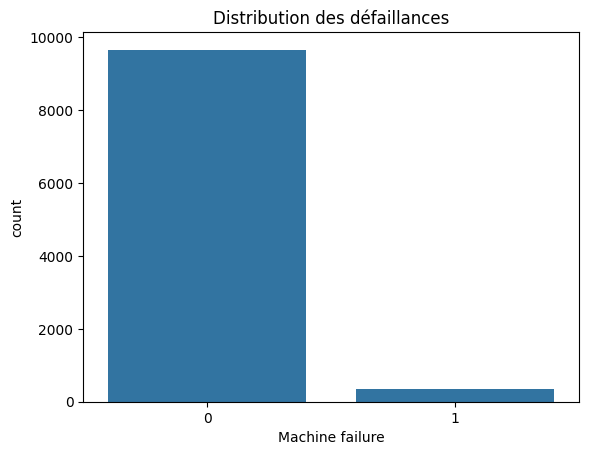

In [19]:
sns.countplot(x='Machine failure', data=df)
plt.title('Distribution des défaillances')
plt.show()


### Corrélation heatmap

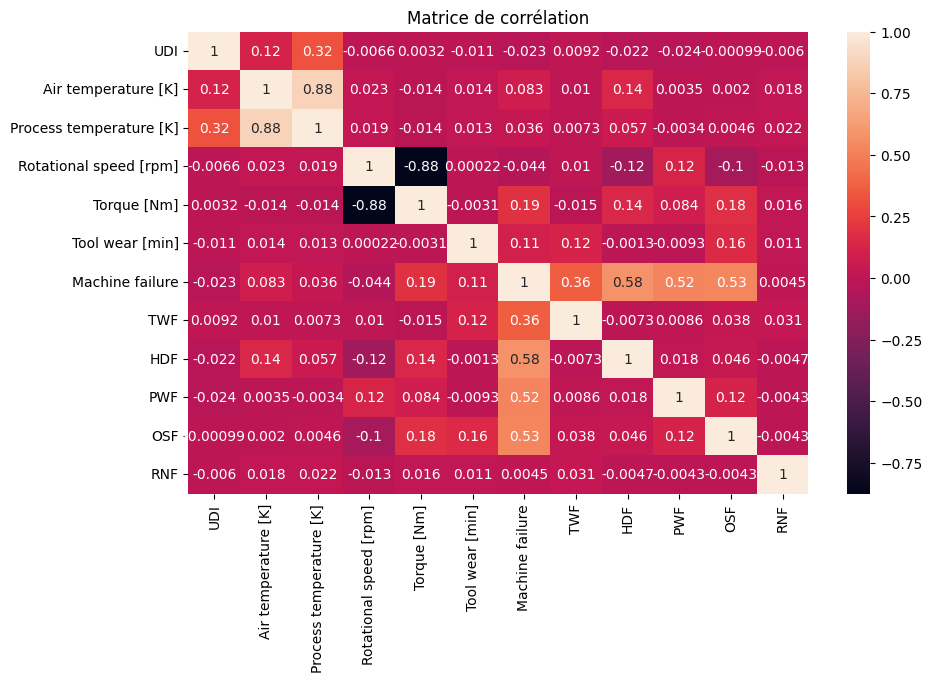

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True) 
plt.title('Matrice de corrélation')
plt.show()

### Distribution des types de machines

In [21]:
fig = px.pie(df, names='Type', title='Distribution des types de machines')
fig.show()
fig.write_image("../outputs/distribution_types.png")

### Distribution des pannes par type de machine

In [22]:
fig = px.bar(
    df.groupby('Type')['Machine failure'].mean().reset_index(),
    x='Type', y='Machine failure',
    title='Taux de pannes par type de machine',
    labels={'Machine failure': 'Taux de panne'},
    color='Type'
)
fig.show()
fig.write_image("../outputs/distribution_pannes_par_types.png")

### Distribution des modes de panne

In [23]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
counts = df[failure_modes].sum().reset_index()
counts.columns = ['Mode', 'Nombre']

fig = px.bar(counts, x='Mode', y='Nombre',
    title='Nombre de cas par mode de panne',
    color='Mode')
fig.show()
fig.write_image("../outputs/distribution_modes_panne.png")

### Corrélation entre les variables (avec plotly)

In [24]:
fig = px.imshow(
    df.select_dtypes(include='number').corr().round(2),
    title='Matrice de corrélation',
    text_auto=True,
    color_continuous_scale='RdBu_r'
)
fig.show()
fig.write_image("../outputs/corrélation_plotly.png")

## 7. Conclusions de l'exploration

### Structure du dataset
- **10 000 lignes, 14 colonnes** — dataset propre, aucune valeur manquante
- Colonnes `UDI` et `Product ID` à supprimer lors du nettoyage (aucune valeur ML)
- La colonne `Type` (L/M/H) devra être encodée numériquement pour le modèle

### Distribution des machines
- **60% de type L** (Low quality), 30% M, 10% H
- Dataset déséquilibré en termes de types — à prendre en compte dans le modèle

### Pannes — dataset très déséquilibré
- Seulement **~3.4% de pannes** sur 10 000 observations (≈ 339 cas)
- C'est un problème classique de **class imbalance** → on devra utiliser
  des techniques comme SMOTE, class_weight ou un seuil de décision ajusté

### Modes de panne
| Mode | Cas | Description |
|------|-----|-------------|
| HDF | 115 | Dissipation thermique insuffisante |
| TWF | 120 | Usure outil excessive |
| OSF | 98  | Surintensité outil |
| PWF | 95  | Puissance hors plage |
| RNF | 5   | Panne aléatoire (non prédictible) |

- **RNF est non prédictible** par nature → à exclure ou traiter séparément
- Les modes peuvent se **cumuler** sur un même point

### Corrélations clés (matrice)
- `Torque` et `Rotational speed` sont **fortement corrélés négativement** (~-0.88)
  → logique physiquement : puissance = couple × vitesse
- `Tool wear` corrèle avec `OSF` et `TWF` → variable très prédictive
- `Air temperature` et `Process temperature` sont **très corrélées** (~0.88)
  → on pourrait créer une feature `delta_temperature = process_temp - air_temp`

### Features engineering à prévoir
- `delta_temperature` = Process temp − Air temp (clé pour HDF)
- `power` = Torque × Rotational speed × (2π/60) (clé pour PWF)
- `tool_wear_torque` = Tool wear × Torque (clé pour OSF)
- Encodage `Type` : L→0, M→1, H→2

### Stratégie ML
- **Objectif principal** : classification binaire `Machine failure` (0/1)
- **Objectif secondaire** : classification multi-label des 5 modes de panne
- Algorithmes à tester : Random Forest, XGBoost, puis peut-etre réseau de neurones PyTorch
- Métrique principale : **F1-score** (pas l'accuracy — dataset déséquilibré)